In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [273]:
class Configuration:
    def __init__(self, NUM: int, rule: list, t: int = 100):
        
        self.NUM = NUM
        self.time_of_life = t
        self.rule = rule

        self.lattice = np.array([np.random.randint(0, 2, N) for _ in range(NUM)])
        
        self.weights = np.array([pow(2,i) for i in range(9)])

    def _get_rule_num(self):
        weights = self.weights
        lattice = self.lattice
        n = (
            weights[0] * np.roll(lattice, (1,1), axis=(0,1)) + weights[1] * np.roll(lattice, 1, axis=0) + weights[2] * np.roll(lattice, (1,-1), axis=(0,1)) +
            weights[3] * np.roll(lattice, 1, axis=1) + weights[4] * lattice + weights[5] * np.roll(lattice, -1, axis=1) +
            weights[6] * np.roll(lattice, (-1,1), axis=(0,1)) + weights[7] * np.roll(lattice, -1, axis=0) + weights[8] * np.roll(lattice, (-1,-1), axis=(0,1))
        )
        return n

    def _update_lattice(self):
        n = self._get_rule_num()
        self.lattice = self.rule[n]

    
    def _fit_function(self):
        scores = np.zeros_like(self.lattice)
        lattice = self.lattice
        
        scores += 8 * (np.roll(lattice, (1,1), axis=(0,1)) == lattice) - 5 * (np.roll(lattice, (1,1), axis=(0,1)) != lattice) 
        scores += 8 * (np.roll(lattice, (-1,1), axis=(0,1)) == lattice) - 5 * (np.roll(lattice, (-1,1), axis=(0,1)) != lattice) 
        scores += 8 * (np.roll(lattice, (1,-1), axis=(0,1)) == lattice) - 5 * (np.roll(lattice, (1,-1), axis=(0,1)) != lattice) 
        scores += 8 * (np.roll(lattice, (-1,-1), axis=(0,1)) == lattice) - 5 * (np.roll(lattice, (-1,-1), axis=(0,1)) != lattice) 
        
        scores += -3 * (np.roll(lattice, 1, axis=0) == lattice)
        scores += -3 * (np.roll(lattice, 1, axis=1) == lattice)
        scores += -3 * (np.roll(lattice, -1, axis=0) == lattice)
        scores += -3 * (np.roll(lattice, -1, axis=1) == lattice)
        
        return scores
        
    def simulate_lifetimes(self):
        for _ in range(self.time_of_life - 11):
            self._update_lattice()
        finess = []
        for _ in range(11):
            self._update_lattice()
            finess.append(np.sum(self._fit_function()))
        return np.average(finess)
    def plot_fitness_function(self):
        fitness = []
        for _ in range(self.time_of_life):
            self._update_lattice()
            fitness.append(np.sum(self._fit_function()))
        plt.plot(fitness)
    def plot_lattice(self):
        plt.imshow(self.lattice, interpolation="nearest", cmap="Greys")
        plt.axis("off")

In [274]:
class Evolution:
    def __init__(self, num_of_rules: int = 20, num_of_cells: int = 50, t: int = 100):
        self.num_of_rules = num_of_rules
        self.NUM = num_of_cells
        self.t = t
        
        self.rules = np.array([np.random.randint(0,2,512) for _ in range(self.num_of_rules)])
        self.top_rule = self.rules[0]
        self.top_score = -99999999999999999
        self.fitness_life = []
    def _competition(self, est_num_of_clones: int):
        rules_score = []
        for rule in self.rules:
            conf = Configuration(NUM=self.NUM, rule=rule, t=self.t)
            rules_score.append(max(conf.simulate_lifetimes(), 0))
        total_score = np.sum(rules_score)
        return np.array([round(score/total_score*est_num_of_clones) for score in rules_score])

    def _children(self, top_rules: np.ndarray, num_of_childs: int):
    
        def mutation(rules: np.ndarray, mut_rate: float = 0.01):
            mask = np.random.random(rules.shape) < mut_rate
            rules ^= mask
            return rules
    
        num_of_rules = len(top_rules)
        children = []
        for _ in range(num_of_childs):
            p1 = top_rules[np.random.randint(num_of_rules)]
            p2 = top_rules[np.random.randint(num_of_rules)]
        
            mask = np.random.randint(0, 2, 512).astype(bool)
        
            child = np.where(mask, p1, p2)
            children.append(child)
        return mutation(np.array(children))

    def _new_generation(self, est_num_of_clones: int = 0):
        if est_num_of_clones <= 0:
            results = self._competition(self.num_of_rules // 2)
        else:
            results = self._competition(est_num_of_clones)
        top_score = results.max()
        if top_score > self.top_score:
            self.top_score = top_score
            self.top_rule = self.rules[results.argmax()]
        else:
            self.rules[results.argmax()] = self.top_rule
        self.fitness_life.append(self.top_score)
        new_rules = np.repeat(self.rules, result, axis=0)
        return np.concatenate([new_rules, self._children(new_rules, self.num_of_rules - len(new_rules))], axis=0)
        
    def get_top_rule(self):
        return self.top_rule
        
    def find_best(self, time_of_life: int):
        for _ in range(time_of_life):
            self.rules = self._new_generation()

        rule = self.get_top_rule()
        conf = Configuration(NUM=self.NUM, rule=rule, t=self.t)
        conf.simulate_lifetimes()
        return conf
    def plot_fitness(self):
        plt.plot(self.fitness_life)

In [277]:
evol = Evolution(t=50)
conf = evol.find_best(300)

/tmp/ipykernel_461014/3697367797.py:17: RuntimeWarning: invalid value encountered in scalar divide
  return np.array([round(score/total_score*est_num_of_clones) for score in rules_score])


ValueError: cannot convert float NaN to integer

In [ ]:
evol.plot_fitness()

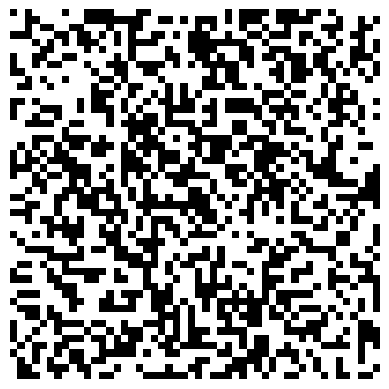

In [275]:
conf.plot_lattice()

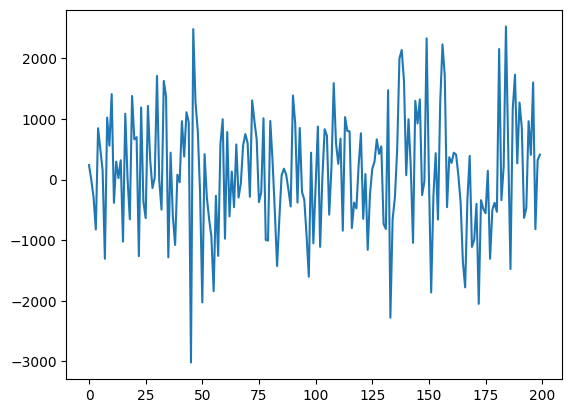

In [276]:
conf.plot_fitness_function()

In [117]:
def generate_rule():
    return np.random.randint(0, 2, 512)

In [210]:
def competition(rules, NUM: int = 50, est_num_of_clones: int = 10):
    rules_score = []
    for rule in rules:
        conf = Configuration(NUM=NUM, rule=rule)
        rules_score.append(max(conf.simulate_lifetimes(), 0))
    total_score = np.sum(rules_score)
    return [round(score/total_score*est_num_of_clones) for score in rules_score]

In [221]:
rules = np.array([np.random.randint(0,2,512) for _ in range(20)])
result = competition(rules)
new_rules = np.repeat(rules, result, axis=0)
new_rules = np.concatenate([new_rules, children(new_rules, len(rules) - len(new_rules))], axis=0)
new_rules.shape, sum(result)

((20, 512), 9)

In [194]:
def children(top_rules: np.ndarray, num_of_childs: int = 15):
    
    def mutation(rules: np.ndarray, mut_rate: float = 0.01):
        mask = np.random.random(rules.shape) < mut_rate
        rules ^= mask
        return rules

    num_of_rules = len(top_rules)
    children = []
    for _ in range(num_of_childs):
        p1 = top_rules[np.random.randint(num_of_rules)]
        p2 = top_rules[np.random.randint(num_of_rules)]
    
        mask = np.random.randint(0, 2, 512).astype(bool)
    
        child = np.where(mask, p1, p2)
        children.append(child)
    return mutation(np.array(children))

In [222]:
def new_generation(rules: np.ndarray):
    orig_len = len(rules)
    results = competition(rules, orig_len // 2)
    new_rules = np.repeat(rules, result, axis=0)
    return np.concatenate([new_rules, children(new_rules, orig_len - len(new_rules))], axis=0)